# 03 - Gradient Boosting

Notebook 02 gave us a baseline of **0.1664** and the tools to measure any model
on four validation windows. Now we train a real model and see whether it earns
its extra cost.

The rule we set for ourselves is strict. The model has to beat the baseline on
the average **and** on every single window. A good average can hide a window
where the model is worse than a median.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import FeatureBuilder
from src.model import SalesModel
from src.metrics import rmspe, rmspe_by
from src.validation import RollingOriginSplit
from src.experiment import run_cv, compare

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

df = DataLoader(PROJECT_ROOT / "data").load()
folds = list(RollingOriginSplit(n_splits=4).split(df))
print("Rows:    ", f"{df.height:,}")
print("Features:", len(FeatureBuilder().fit(df).feature_names_))

Rows:     844,392


Features: 24


## The model

`SalesModel` is XGBoost with two decisions built in.

**It learns on the logarithm of the sales.** RMSPE reads every error as a
percentage. If the model trains on the raw sales, it works hardest on the large
stores, because their errors are larger in absolute numbers. In log space, a
step of ten percent is the same distance for a small store and for a large one,
so the training goal matches the metric. We test this below.

**It counts its trees on an inner window.** Early stopping needs a set to
watch. If we watched the validation window, we would choose the number of trees
on the very rows we score, and the result would look better than it is. So we
cut the last six weeks off the training data, find the best number of trees
there, and then train the final model on the whole training set with that
number.

Let us train one fold and look at it.

In [2]:
fold = folds[-1]  # the newest window

builder = FeatureBuilder().fit(fold.train)   # learns from training rows only
train_x = builder.transform(fold.train)
valid_x = builder.transform(fold.valid)

model = SalesModel().fit(train_x, builder.feature_names_)
prediction = model.predict(valid_x)

print(f"Trees chosen on the inner window: {model.best_rounds_}")
print(f"Fold {fold.index} ({fold.valid_start} to {fold.valid_end})")
print(f"  XGBoost RMSPE: {rmspe(valid_x['Sales'], prediction):.4f}")
print(f"  Baseline RMSPE: 0.1449")

Trees chosen on the inner window: 382
Fold 4 (2015-06-20 to 2015-07-31)
  XGBoost RMSPE: 0.1315
  Baseline RMSPE: 0.1449


Note where `FeatureBuilder` is fitted: **inside** the fold, on the training
rows only. The store averages and the promotion uplifts are learned from the
target, so if we fitted them once on the whole table, the validation window
would leak into the features and the score would be wrong. Every run below
repeats this fit inside every fold.

## Does the logarithm really matter?

We now run three approaches over all four windows: the baseline, the model on
the logarithm of the sales, and the same model on the raw sales.

`run_cv` does the loop. It asks for a function that trains on the rows of one
fold and returns the validation rows with a prediction, so the fit stays inside
the fold.

In [3]:
def baseline_fit_predict(train, valid):
    """Median sales per store, weekday and promotion state."""
    lookup = train.group_by(["Store", "DayOfWeek", "Promo"]).agg(
        pl.col("Sales").median().alias("prediction")
    )
    per_store = train.group_by("Store").agg(pl.col("Sales").median().alias("_store"))
    overall = float(train["Sales"].median())
    return (
        valid.join(lookup, on=["Store", "DayOfWeek", "Promo"], how="left")
        .join(per_store, on="Store", how="left")
        .with_columns(pl.col("prediction").fill_null(pl.col("_store")).fill_null(overall))
    )


def xgboost_fit_predict(log_target=True, extra_features=()):
    """Build a fit_predict function for XGBoost."""

    def fit_predict(train, valid):
        builder = FeatureBuilder().fit(train)
        train_x = builder.transform(train)
        valid_x = builder.transform(valid)
        features = list(builder.feature_names_) + list(extra_features)
        model = SalesModel(log_target=log_target).fit(train_x, features)
        return valid_x.with_columns(pl.Series("prediction", model.predict(valid_x)))

    return fit_predict

In [4]:
runs = {}
scored = {}

runs["baseline"], scored["baseline"] = run_cv(df, baseline_fit_predict)
runs["xgboost (log)"], scored["xgboost (log)"] = run_cv(df, xgboost_fit_predict())
runs["xgboost (raw sales)"], _ = run_cv(df, xgboost_fit_predict(log_target=False))

print(compare(runs))

shape: (5, 4)
┌──────┬──────────┬───────────────┬─────────────────────┐
│ fold ┆ baseline ┆ xgboost (log) ┆ xgboost (raw sales) │
│ ---  ┆ ---      ┆ ---           ┆ ---                 │
│ str  ┆ f64      ┆ f64           ┆ f64                 │
╞══════╪══════════╪═══════════════╪═════════════════════╡
│ 1    ┆ 0.187735 ┆ 0.180584      ┆ 0.190697            │
│ 2    ┆ 0.174555 ┆ 0.146416      ┆ 0.155541            │
│ 3    ┆ 0.158443 ┆ 0.130452      ┆ 0.135044            │
│ 4    ┆ 0.144941 ┆ 0.131531      ┆ 0.139621            │
│ mean ┆ 0.166419 ┆ 0.147246      ┆ 0.155226            │
└──────┴──────────┴───────────────┴─────────────────────┘


The logarithm is worth about **0.008**, which is five percent of the score. That
is a large gain for a one line change.

The first window shows it best. Without the logarithm, XGBoost scores 0.1907
there, and the simple baseline scores 0.1877. So the model with the raw target
**loses to a median** on the hardest window, while the same model with the
logarithm wins on all four.

This is the point we made in the plan: matching the loss to the metric is worth
more than any parameter tuning.

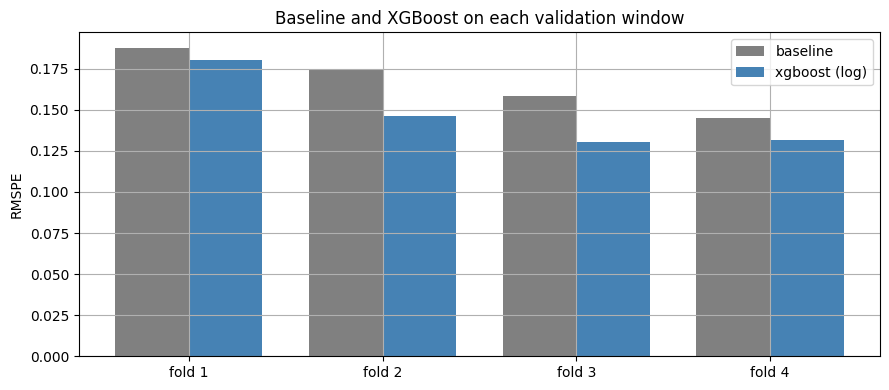

fold 1: XGBoost is 3.8 percent better than the baseline
fold 2: XGBoost is 16.1 percent better than the baseline
fold 3: XGBoost is 17.7 percent better than the baseline
fold 4: XGBoost is 9.3 percent better than the baseline


In [5]:
x = np.arange(1, 5)
width = 0.38
plt.bar(x - width / 2, runs["baseline"]["rmspe"].to_list(), width,
        label="baseline", color="gray")
plt.bar(x + width / 2, runs["xgboost (log)"]["rmspe"].to_list(), width,
        label="xgboost (log)", color="steelblue")
plt.xticks(x, [f"fold {i}" for i in x])
plt.ylabel("RMSPE")
plt.title("Baseline and XGBoost on each validation window")
plt.legend()
plt.tight_layout()
plt.show()

gain = 1 - runs["xgboost (log)"]["rmspe"] / runs["baseline"]["rmspe"]
for i, g in enumerate(gain.to_list(), start=1):
    print(f"fold {i}: XGBoost is {100 * g:.1f} percent better than the baseline")

XGBoost wins on every window, so it passes our rule.

The size of the win is not the same everywhere. On folds 2 and 3 the model is
about 17 percent better, but on fold 1 only about 4 percent. Fold 1 was already
the hardest window for the baseline, and it stays the hardest here. Whatever
makes that spring window difficult, more model power does not remove it.

## What does the model use?

`gain` tells us how much each feature improved the splits it was used in.

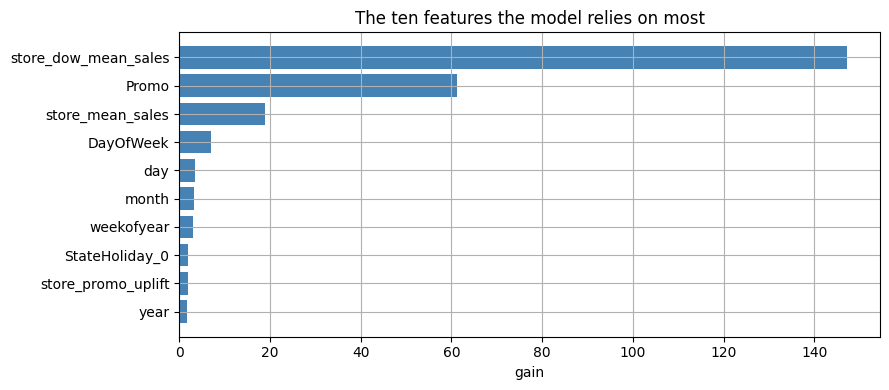

shape: (10, 2)
┌──────────────────────┬───────────┐
│ feature              ┆ gain      │
│ ---                  ┆ ---       │
│ str                  ┆ f64       │
╞══════════════════════╪═══════════╡
│ store_dow_mean_sales ┆ 147.11116 │
│ Promo                ┆ 61.329937 │
│ store_mean_sales     ┆ 18.982639 │
│ DayOfWeek            ┆ 6.908208  │
│ day                  ┆ 3.472125  │
│ month                ┆ 3.257618  │
│ weekofyear           ┆ 3.121448  │
│ StateHoliday_0       ┆ 1.996241  │
│ store_promo_uplift   ┆ 1.859956  │
│ year                 ┆ 1.822621  │
└──────────────────────┴───────────┘


In [6]:
importance = model.importance("gain")
top = importance.head(10)

plt.barh(top["feature"].to_list()[::-1], top["gain"].to_list()[::-1], color="steelblue")
plt.xlabel("gain")
plt.title("The ten features the model relies on most")
plt.tight_layout()
plt.show()

print(importance.head(10))

Three features carry almost everything: the average sales of the store on that
weekday, the promotion flag, and the average sales of the store.

This says something about the baseline. Our simple rule used exactly the same
three pieces of information, which is why it was so hard to beat. XGBoost wins
because it can bend those numbers with the calendar and with the store facts,
not because it found a new source of signal.

## A feature that did not work

In the data we found a clear pattern: the longer a store takes part in Promo2,
the more it sells. From the first year to the sixth the average rises by about
twelve percent, and the rise is smooth.

That looked like a free gain, so we built two features for it:

- `promo2_tenure_weeks`: the weeks since the store joined Promo2
- `promo_cycle_pos`: the position of the month in the three month cycle

Now we test them properly, one at a time and together.

In [7]:
extra = {
    "with both": ("promo2_tenure_weeks", "promo_cycle_pos"),
    "tenure only": ("promo2_tenure_weeks",),
    "cycle position only": ("promo_cycle_pos",),
}
ablation = {"without both (our model)": runs["xgboost (log)"]}
for name, columns in extra.items():
    ablation[name], _ = run_cv(df, xgboost_fit_predict(extra_features=columns))

print(compare(ablation))

shape: (5, 5)
┌──────┬──────────────────────────┬───────────┬─────────────┬─────────────────────┐
│ fold ┆ without both (our model) ┆ with both ┆ tenure only ┆ cycle position only │
│ ---  ┆ ---                      ┆ ---       ┆ ---         ┆ ---                 │
│ str  ┆ f64                      ┆ f64       ┆ f64         ┆ f64                 │
╞══════╪══════════════════════════╪═══════════╪═════════════╪═════════════════════╡
│ 1    ┆ 0.180584                 ┆ 0.177918  ┆ 0.176628    ┆ 0.176417            │
│ 2    ┆ 0.146416                 ┆ 0.146424  ┆ 0.154738    ┆ 0.154881            │
│ 3    ┆ 0.130452                 ┆ 0.127195  ┆ 0.127154    ┆ 0.127955            │
│ 4    ┆ 0.131531                 ┆ 0.135195  ┆ 0.131939    ┆ 0.130212            │
│ mean ┆ 0.147246                 ┆ 0.146683  ┆ 0.147615    ┆ 0.147366            │
└──────┴──────────────────────────┴───────────┴─────────────┴─────────────────────┘


Nothing happens. The four means sit between 0.1467 and 0.1476.

There is a detail here that says more than the table itself. The version
"without both" is our model from before, and it repeats its score exactly:
0.1472. The other three move by a few thousandths, and the order changes from
fold to fold. A version that wins on fold 1 loses on fold 2.

Part of that movement is not even about the features. The model draws 80
percent of the columns for each tree, so adding a column at the end of the list
changes which columns each tree sees. The gaps between these four versions are
therefore smaller than the noise that a simple change of column order creates.
There is nothing to measure here.

The reason is visible in the importance chart above. The model already knows
`store_mean_sales`. The stores that joined Promo2 early are simply the stores
that sell more, and the model has that information already. The twelve percent
rise was a fact about *which stores joined when*, not about the effect of
taking part longer.

So we leave both features out. They are still built in `FeatureBuilder`, and a
comment there records this test, but they are not part of the model.

This is why we build the measuring tools before the model. A pattern in the raw
data is a question, not an answer.

## Where does the error sit now?

The average tells us little about the weak spots. We split the error of the
newest window by store type and by store size, for both models.

In [8]:
newest_baseline = scored["baseline"][4]
newest_xgboost = scored["xgboost (log)"][4]


def side_by_side(group_col: str) -> pl.DataFrame:
    a = rmspe_by(newest_baseline, group_col).select([group_col, pl.col("rmspe").alias("baseline"), "rows"])
    b = rmspe_by(newest_xgboost, group_col).select([group_col, pl.col("rmspe").alias("xgboost")])
    return (
        a.join(b, on=group_col, how="left")
        .with_columns((1 - pl.col("xgboost") / pl.col("baseline")).alias("gain"))
        .sort(group_col)
    )


print("By store type")
print(side_by_side("StoreType"))

# Store size, measured on the training rows of the fold so we do not peek.
size = folds[-1].train.group_by("Store").agg(pl.col("Sales").mean().alias("mean_sales"))
cuts = np.percentile(size["mean_sales"].to_numpy(), [25, 50, 75])
size = size.with_columns(
    pl.when(pl.col("mean_sales") < cuts[0]).then(pl.lit("Q1 small"))
    .when(pl.col("mean_sales") < cuts[1]).then(pl.lit("Q2"))
    .when(pl.col("mean_sales") < cuts[2]).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4 large")).alias("size_group")
)
newest_baseline = newest_baseline.join(size.select(["Store", "size_group"]), on="Store", how="left")
newest_xgboost = newest_xgboost.join(size.select(["Store", "size_group"]), on="Store", how="left")

print("\nBy store size")
print(side_by_side("size_group"))

By store type
shape: (4, 5)
┌───────────┬──────────┬───────┬──────────┬──────────┐
│ StoreType ┆ baseline ┆ rows  ┆ xgboost  ┆ gain     │
│ ---       ┆ ---      ┆ ---   ┆ ---      ┆ ---      │
│ str       ┆ f64      ┆ u32   ┆ f64      ┆ f64      │
╞═══════════╪══════════╪═══════╪══════════╪══════════╡
│ a         ┆ 0.148706 ┆ 21694 ┆ 0.136313 ┆ 0.083341 │
│ b         ┆ 0.152588 ┆ 714   ┆ 0.103625 ┆ 0.320883 │
│ c         ┆ 0.146895 ┆ 5328  ┆ 0.133631 ┆ 0.090295 │
│ d         ┆ 0.136839 ┆ 12546 ┆ 0.12338  ┆ 0.098361 │
└───────────┴──────────┴───────┴──────────┴──────────┘

By store size
shape: (4, 5)
┌────────────┬──────────┬───────┬──────────┬──────────┐
│ size_group ┆ baseline ┆ rows  ┆ xgboost  ┆ gain     │
│ ---        ┆ ---      ┆ ---   ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ u32   ┆ f64      ┆ f64      │
╞════════════╪══════════╪═══════╪══════════╪══════════╡
│ Q1 small   ┆ 0.149773 ┆ 10063 ┆ 0.134229 ┆ 0.103788 │
│ Q2         ┆ 0.152093 ┆ 10039 ┆ 0.140142 ┆ 0.078579 │
│

The model improves every group, but not by the same amount.

Across store sizes the gains are close together, between 8 and 10 percent, and
the error stays flat over the four quartiles, just as it was for the baseline.
No size group is handled badly.

Store type `b` is the exception. Its error falls by 32 percent, from 0.153 to
0.104, which is far more than any other group. These are the 17 large stores
that already stood out in the exploratory notebook. The median rule handled
them badly and the model does not. Please read this number with care, because
it rests on only 714 rows.

This matters for the next step, where we ask whether groups of similar stores
deserve their own models. The size groups give no reason to split, since none
of them is weak. Store type `b` points the other way, but 17 stores are far too
few to train a model on, and the single model has already solved most of their
problem. We will still test the question, because an argument is not a
measurement.

## Key findings

1. XGBoost on the logarithm of the sales scores **0.1472**, against **0.1664**
   for the baseline. That is about twelve percent better, and it wins on all
   four windows, so it passes our rule.
2. The logarithm is worth **0.008** on its own. Without it the model even loses
   to the baseline on the hardest window. Matching the loss to the metric is
   the most valuable decision in this notebook.
3. The model leans on three features: the average sales of the store on that
   weekday, the promotion flag, and the average sales of the store. The
   baseline used the same three, which is why it was hard to beat.
4. The Promo2 tenure features were **tested and rejected**. The twelve percent
   pattern in the raw data was about which stores joined early, and the model
   already knew those stores. The differences were smaller than the noise from
   changing the column order.
5. Fold 1 stays hard for both models. More model power does not fix whatever
   makes that spring window difficult.
6. The error is flat across store sizes, and each quartile gains a similar
   amount. Store type `b` gains much more, but it holds only 17 stores. Both
   facts are early arguments against building one model per group of stores.